In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
# Load iris dataset
iris = load_iris()

In [3]:
# Extract sepal length and petal length features
X = iris.data[:, [0, 2]]
y = iris.target

In [4]:
# Setosa is class 0, versicolor & virginica are class 1
y = np.where(y == 0, 0, 1)

# Initialize weights and bias
w = np.zeros(2)
b = 0

# Set learning rate and number of epochs
lr = 0.1
epochs = 50

In [5]:
# Define perceptron function
def perceptron(x, w, b):

    # Calculate weighted sum of inputs
    z = np.dot(x, w) + b

    # Apply step function
    return np.where(z >= 0, 1, 0)

In [6]:
# Train the perceptron
for epoch in range(epochs):

    for i in range(len(X)):

        x = X[i]
        target = y[i]

        output = perceptron(x, w, b)

        error = target - output

        w += lr * error * x
        b += lr * error

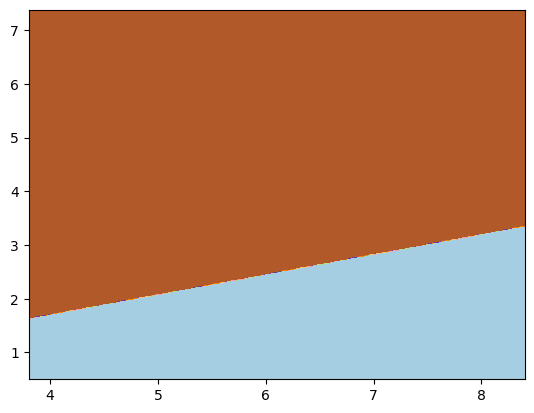

In [7]:
# Plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = perceptron(np.c_[xx.ravel(), yy.ravel()], w, b)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)


Text(0.5, 1.0, 'Perceptron Decision Regions')

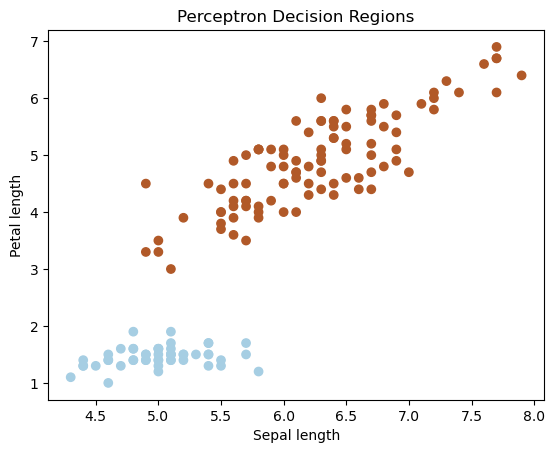

In [8]:
# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)

plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.title('Perceptron Decision Regions')